Minimal version: cumulative CSI-object score-vs-outcome plot in the single-panel paper layout.

This notebook filters to the full-image `fix_nonmask` and `fix_mask` settings, sorts by the CSI object mask score, and plots cumulative `Safe`, `Unknown`, and `Unsafe` outcome curves for `$\alpha\beta$-CROWN + CSI [object]` in the single-panel paper layout.


Using CSV: /Users/zd3504phd/Desktop/XAIV/results/vggnet16/ALL_vggnet_flipped.csv
Dataset: ImageNet
Paired rows: 181, $\epsilon=0.0001$, k=50176
$\alpha\beta$-CROWN w/ CSI [object]: {'safe': 58, 'unknown': 28, 'unsafe': 95}
Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.4.3_seg_score/imagenet_score_vs_outcome_k50176_csi_only_cumulative_flipped.pdf


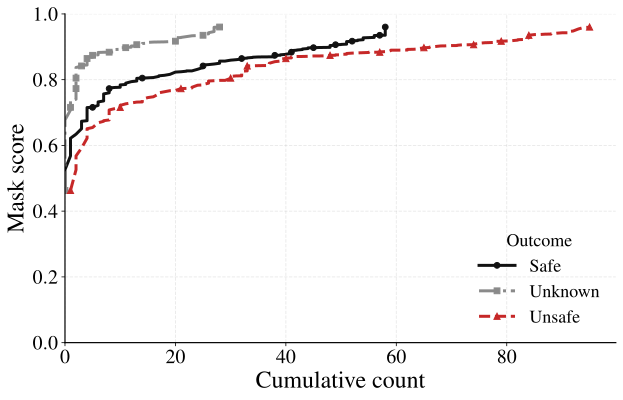

In [1]:
import os
import shutil
import subprocess
from pathlib import Path


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "plots").exists() and ((candidate / "analysis").exists() or (candidate / "results").exists()):
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
PLOT_DIR = PROJECT_ROOT / "plots" / "5.4.3_seg_score"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = PLOT_DIR / ".cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

texlive_root = Path("/opt/homebrew/Cellar/texlive")
tex_bin_candidates = [
    Path("/opt/homebrew/opt/texlive/bin"),
    *sorted(texlive_root.glob("*/bin"), reverse=True),
    Path("/opt/homebrew/bin"),
    Path("/Library/TeX/texbin"),
    Path("/usr/texbin"),
]
tex_lib_candidates = [
    Path("/opt/homebrew/opt/libpng/lib"),
    Path("/opt/homebrew/opt/texlive/lib"),
    *sorted(texlive_root.glob("*/lib"), reverse=True),
]

current_path = os.environ.get("PATH", "")
path_parts = current_path.split(":") if current_path else []
for texbin in tex_bin_candidates:
    if texbin.exists():
        texbin_str = str(texbin)
        if texbin_str not in path_parts:
            path_parts.insert(0, texbin_str)
os.environ["PATH"] = ":".join(path_parts)

current_dyld = os.environ.get("DYLD_LIBRARY_PATH", "")
dyld_parts = current_dyld.split(":") if current_dyld else []
for texlib in tex_lib_candidates:
    if texlib.exists():
        texlib_str = str(texlib)
        if texlib_str not in dyld_parts:
            dyld_parts.insert(0, texlib_str)
if dyld_parts:
    os.environ["DYLD_LIBRARY_PATH"] = ":".join(dyld_parts)

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
except ImportError:
    set_matplotlib_formats = None

FORCE_TEX = True
CSI_OBJECT_LABEL = r"$\alpha\beta$-CROWN w/ CSI [object]"
RESULT_ORDER = ["safe", "unknown", "unsafe"]
RESULT_LABELS = {
    "safe": "Safe",
    "unknown": "Unknown",
    "unsafe": "Unsafe",
}
OUTCOME_STYLES = {
    "safe": {
        "color": "#111111",
        "linestyle": "-",
        "linewidth": 3.0,
        "marker": "o",
        "markersize": 5.8,
        "markerfacecolor": "#111111",
        "markeredgecolor": "#111111",
    },
    "unknown": {
        "color": "#8a8a8a",
        "linestyle": "-.",
        "linewidth": 3.0,
        "marker": "s",
        "markersize": 5.8,
        "markerfacecolor": "#8a8a8a",
        "markeredgecolor": "#8a8a8a",
    },
    "unsafe": {
        "color": "#c62828",
        "linestyle": "--",
        "linewidth": 3.0,
        "marker": "^",
        "markersize": 6.2,
        "markerfacecolor": "#c62828",
        "markeredgecolor": "#c62828",
    },
}


def latex_ready():
    has_renderer = shutil.which("dvipng") is not None or shutil.which("dvisvgm") is not None
    return shutil.which("latex") is not None and has_renderer


def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0


def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if set_matplotlib_formats is not None:
        if use_tex and shutil.which("dvisvgm") is not None:
            set_matplotlib_formats("svg")
        else:
            set_matplotlib_formats("png")

    if force_tex and not use_tex:
        print("LaTeX was requested but no compatible renderer was found. Falling back to Matplotlib serif text.")

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "text.latex.preamble": preamble,
        "font.size": 18,
        "axes.labelsize": 24,
        "axes.titlesize": 22,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 18,
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex


def resolve_existing_path(candidates, description):
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return candidate
    checked = "\n".join(str(path.resolve()) for path in candidates)
    raise FileNotFoundError(f"Could not find the {description} CSV. Checked:\n{checked}")


def canon_result(value):
    text = str(value).lower()
    if "unsat" in text:
        return "safe"
    if "sat" in text:
        return "unsafe"
    return "unknown"


def cumulative_count(series, label):
    hits = (series == label).astype(int).to_numpy()
    return hits.cumsum()


def load_paired_scores(csv_candidates, description):
    csv_path = resolve_existing_path(csv_candidates, description)
    df = pd.read_csv(csv_path)

    for col in ["eps", "k", "total", "segment_index", "score"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in ["tag", "image", "model", "result"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    df = df.dropna(subset=["total", "k"]).copy()
    df = df[df["tag"].isin(["fix_nonmask", "fix_mask"])].copy()
    df["full_k"] = (df["total"] // 3).astype(int)
    df = df[df["k"].astype(int) == df["full_k"]].copy()

    if df.empty:
        raise ValueError(f"No {description} rows remain after filtering for fix_nonmask/fix_mask and full-image coverage.")

    df["result_cat"] = df["result"].apply(canon_result)
    key_pair = [col for col in ["model", "image", "segment_index", "eps", "k", "total"] if col in df.columns]

    object_df = (
        df[df["tag"] == "fix_nonmask"][key_pair + ["score", "result_cat"]]
        .rename(columns={"score": "mask_score", "result_cat": "obj_result"})
        .dropna(subset=["mask_score"])
        .drop_duplicates(subset=key_pair, keep="first")
        .copy()
    )

    background_df = (
        df[df["tag"] == "fix_mask"][key_pair + ["result_cat"]]
        .rename(columns={"result_cat": "bg_result"})
        .drop_duplicates(subset=key_pair, keep="first")
        .copy()
    )

    paired = object_df.merge(background_df, on=key_pair, how="inner")

    if paired.empty:
        raise ValueError(f"No paired {description} fix_nonmask/fix_mask rows found after filtering.")

    paired = paired.sort_values("mask_score").reset_index(drop=True)
    return csv_path, paired


def save_plot_name(stem, k_values):
    if len(k_values) == 1:
        return f"{stem}_score_vs_outcome_k{k_values[0]}_csi_only_cumulative_flipped.pdf"
    return f"{stem}_score_vs_outcome_csi_only_cumulative_flipped.pdf"


def plot_csi_object_background(paired, csv_path, dataset_label, output_stem):
    y = paired["mask_score"].to_numpy()
    curves = {label: cumulative_count(paired["obj_result"], label) for label in RESULT_ORDER}
    max_count = max(curve.max() for curve in curves.values())
    x_upper = max(max_count * 1.05, 1)

    eps_values = paired["eps"].dropna().unique()
    k_values = paired["k"].dropna().astype(int).unique()
    eps_text = rf", $\epsilon={eps_values[0]:g}$" if len(eps_values) == 1 else ""
    k_text = f", k={k_values[0]}" if len(k_values) == 1 else ""

    fig, ax = plt.subplots(figsize=(9.0, 5.9))

    for label in RESULT_ORDER:
        style = OUTCOME_STYLES[label]
        curve = curves[label]
        marker_stride = max(len(curve) // 12, 1)
        ax.plot(
            curve,
            y,
            linewidth=style["linewidth"],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=style["markersize"],
            markerfacecolor=style["markerfacecolor"],
            markeredgecolor=style["markeredgecolor"],
            markeredgewidth=1.0,
            markevery=marker_stride,
            label=RESULT_LABELS[label],
        )

    ax.set_xlim(0, x_upper)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Cumulative count")
    ax.set_ylabel("Mask score")
    ax.tick_params(axis="both", labelsize=20)
    ax.grid(True, linestyle="--", alpha=0.28)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="lower right", frameon=False, title="Outcome", title_fontsize=18)

    fig.tight_layout()

    counts = {label: int(curves[label][-1]) for label in RESULT_ORDER}
    pdf_name = save_plot_name(output_stem, k_values)
    pdf_path = PLOT_DIR / pdf_name
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Using CSV: {csv_path}")
    print(f"Dataset: {dataset_label}")
    print(f"Paired rows: {len(paired)}{eps_text}{k_text}")
    print(f"{CSI_OBJECT_LABEL}: {counts}")
    print(f"Saved: {pdf_path}")

    plt.show()


use_tex = configure_plot_style()

IMAGENET_CSV_CANDIDATES = [
    PROJECT_ROOT / "results" / "vggnet16" / "ALL_vggnet_flipped.csv",
]

imagenet_csv_path, paired_imagenet = load_paired_scores(IMAGENET_CSV_CANDIDATES, "ImageNet")
plot_csi_object_background(paired_imagenet, imagenet_csv_path, "ImageNet", "imagenet")
